# Molecular dynamics simulations of a Lennard-Jones-like liquid

In a classical approximation, interactions between atoms consist of a repulsive term due to electron shell overlap and an attractive term due to dipole-dipole interactions. These terms are typically parametrized by the Lennard-Jones potential. For computational convenience, we use the Wang-Frenkel interaction potential between particles $i$ and $j$ instead


$$
U_{ij}^{\mathrm{WF}} =
\begin{cases}
\epsilon \left[ \left( \frac{\sigma}{r_{ij}} \right)^2 - 1 \right]
\left[ \left( \frac{r_c}{r_{ij}} \right)^2 - 1 \right]^2 & \text{if } r_{ij} < r_c \\
0 & \text{otherwise.}
\end{cases}
$$

with $\sigma$ and $\epsilon$ being phenomenological constants and $r_c$ being the cutoff distance. The distance between molecules is denoted $r_{ij}$. We consider a two-dimensional system of spherical molecules with periodic boundary conditions. The molecules all have the same mass $m$.

## 1. Initialization

### (a)

Write a script to generate the positions of a two-dimensional system of molecules with a packing fraction $\phi$, which is defined as

$$
\phi = \frac{N \pi \sigma^2}{A},
$$
with $N$ being the number of molecules and $A$ being the total surface area of
two-dimensional system. Make sure that the molecules do not overlap because
that would lead to very large energies

In [1]:
#1a
import numpy as np
import matplotlib.pyplot as plt 

#Constants
rc = 1.0
sigma = 1.0
epsilon = 1.0
phi = 0.5

#Parameter
N = 100

#function to generate positions with the given tensity 
def generate_positions(N, phi, sigma, factor = 1.0, max_trials=100000):
    positions = []
    cnt = 0

    #calculate A for the chosen N and sigma
    A = (N*np.pi*sigma**2) / phi 

    #quadradic field with sidelenght L
    L = np.sqrt(A)

    #calc minimal distance between two moleculecenters
    min_distance = 2* sigma * factor

    #try as long as their are N molecules or max_tails is reached
    while len(positions) < N and cnt < max_trials:
        p = np.array([np.random.uniform(0, L),
                      np.random.uniform(0, L)])

        # check if their is an overlap
        ok = True
        for q in positions:
            if np.linalg.norm(p - q) < min_distance:
                ok = False
                break

        if ok:
            positions.append(p)

        cnt += 1

    # if the number of paricles cannot be reached within the max 
    # nuber of trails stopp with the error 
    if len(positions) < N:
        raise RuntimeError("density not reachable.")

    return np.array(positions), L


positions, L = generate_positions(N, phi, sigma, 1.0, 1000000)

print("Box length L =", L)
print("Generated positions:")
print(positions)



Box length L = 25.066282746310005
Generated positions:
[[10.35147507 19.48453934]
 [ 0.18099669 16.43872689]
 [10.80675376  5.54791001]
 [12.73012004 12.96952556]
 [10.25940065  9.38658507]
 [10.83877973 23.19163215]
 [24.92767518 18.1320668 ]
 [10.61772899 12.91861944]
 [23.36801237  2.16894311]
 [22.37151288 19.93312435]
 [ 3.8779612  15.40193074]
 [ 6.06174178 14.71783672]
 [16.09888644  8.45248708]
 [13.8752591  10.04062123]
 [ 5.49498501  5.98508799]
 [20.00844856 10.34379839]
 [16.05338375 11.38327769]
 [11.522884   17.43492265]
 [ 1.13155874 14.32986543]
 [20.89217554 17.23915026]
 [ 3.74576954  1.2335849 ]
 [ 2.82150723 19.64805325]
 [20.46703634 23.71653631]
 [13.32949003  7.32887513]
 [16.46338082  4.67674836]
 [15.73653553  1.63064441]
 [21.04265067  5.58530884]
 [19.72480214  7.74375596]
 [ 4.40227963  4.23121881]
 [ 3.98448503 21.70329093]
 [ 0.36469193 25.05394426]
 [ 1.23915767  1.36887763]
 [17.770278   16.26300919]
 [23.76470819 22.30003281]
 [13.06490997 16.14809111]


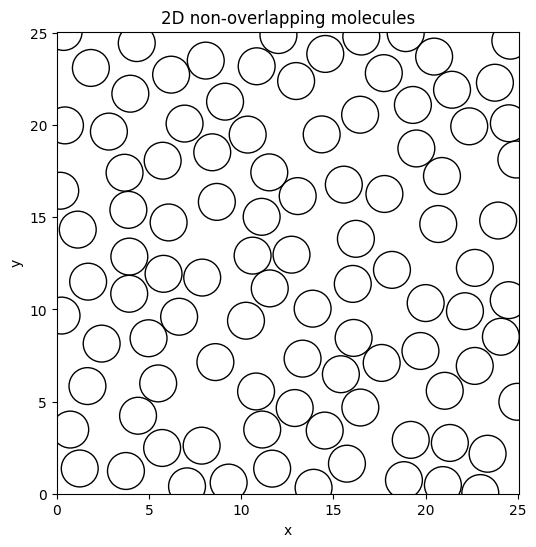

In [2]:
#Testfeld
# plot -> plot particles
fig, ax = plt.subplots(figsize=(6, 6))

for x, y in positions:
    circle = plt.Circle((x, y), sigma, fill=False)
    ax.add_patch(circle)

ax.set_xlim(0, L)
ax.set_ylim(0, L)
ax.set_aspect('equal')
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("2D non-overlapping molecules")
plt.show()

(b) Generate initial velocities for all particles by drawing independent velocities
in every dimension from a Gaussian distribution corresponding to an initial
temperature $T$ . Make sure that the velocity of the center of mass of the system
vanishes.

In [3]:
#1b
# function to generate the velocities
def generate_velocities(N, T, k_B, m):
    # for corresbondig to a Temp use a sigma_v(T)
    # Äquipartitionstheorem 1/2 kb T per dimension
    sigma_v = np.sqrt(k_B*T/m)
    # create velocities
    v = np.random.normal(0.0, sigma_v, size=(N, 2))

    # subtract center-of-mass velocity
    v_cm = np.mean(v, axis=0)
    v_cm_corr = v - v_cm

    return v, v_cm_corr 

# check the function (vanishes v of des center of mass)
N = 1000
m =1.0
k_B = 1.0
T = 1.0

v, v_cm_corr = generate_velocities(N, T, k_B, m)
print("Number of Values", np.shape(v))
print("Means of  direction (without COM correction):", np.mean(v, axis=0))
print("Means of  direction (with COM correction):", np.mean(v_cm_corr, axis=0))
#print(positions)


Number of Values (1000, 2)
Means of  direction (without COM correction): [0.03494238 0.01719055]
Means of  direction (with COM correction): [ 1.66533454e-17 -5.99520433e-18]


2 Force calculation
The force between the molecules is given as usual by $f_{ij} = −\nabla U^{WF}_{ij}$ . The forces
are assumed to be pairwise additive.

    (a) Write a script to calculate the force on all particles from the positions of the particles. Take care that periodic boundary conditions are used.


In [43]:
#2a
def pair_force(vec_rij, epsilon, sigma, rc):
    # absolutvalue of the vector rij
    r = np.sqrt(np.dot(vec_rij,vec_rij))

    # chec if inside the cutoff distance (avoid division 0 )
    if r >= rc or r < 1e-48:
        return np.zeros(2)
    
    # calculate a force
    A = (sigma**2 / r**2) -1.0
    B = (rc**2 / r**2) -1.0
    
    f = vec_rij * (2*epsilon/r**4) * (sigma**2 * B**2 + 2 * A * B * rc**2)
    return f

# test the function
#rc = 10
#i = 0
#j = 6
#rij = positions[i]-positions[j]
#r = np.linalg.norm(rij)
#f = pair_force(rij, epsilon, sigma, rc)
#print(rij)
#print(r)
#print(f)
#print(positions)

# vectorization possible?
def total_forces(positions, L, epsilon, sigma, rc):
    N = len(positions)
    forces = np.zeros_like(positions)
    U_tot = 0
    # seite 79 im scirpt!
    for i in range(N - 1):
        for j in range(i + 1, N):
            rij = positions[i] - positions[j]
            # this is to have periodic poundary conditions
            rij -= L * np.round(rij / L)
            fij  = pair_force(rij, epsilon, sigma, rc)
            # add force to i
            forces[i] += fij
            # same force accts with opposite sign to j
            forces[j] -= fij

    return forces

# Test of te funciton
rc = 7
f_tot = total_forces(positions, L, epsilon, sigma, rc)
idx = np.where(np.linalg.norm(f_tot, axis=1) != 0)[0]
print(L)
print(f_tot[idx])


70.89815403622065
[[ 87.38204969 -87.80843601]
 [ 25.3751832  -24.11807073]
 [-55.08980108 -45.35422831]
 ...
 [ 27.37488753  26.02420588]
 [-12.18386991  70.44406699]
 [ -7.152914    -8.96705531]]


        (b) Include a calculation of the total potential energy of the system in the calculation
of the forces

In [41]:
#2b
def pair_force_potential_Energy(vec_rij, epsilon, sigma, rc):
    # absolutvalue of the vector rij
    r = np.sqrt(np.dot(vec_rij,vec_rij))

    # chec if inside the cutoff distance (avoid division 0 )
    if r >= rc or r < 1e-48:
        return np.zeros(2)
    
    # calculate a force
    A = (sigma**2 / r**2) -1.0
    B = (rc**2 / r**2) -1.0
    
    f = vec_rij * (2*epsilon/r**4) * (sigma**2 * B**2 + 2 * A * B * rc**2)
    U = epsilon*A*B**2
    return f, U

# vectorization possible?
def total_forces_Energy(positions, L, epsilon, sigma, rc):
    N = len(positions)
    forces = np.zeros_like(positions)
    U_tot = 0
    # seite 79 im scirpt!
    for i in range(N - 1):
        for j in range(i + 1, N):
            rij = positions[i] - positions[j]
            # this is to have periodic poundary conditions
            rij -= L * np.round(rij / L)
            fij, Uij  = pair_force_potential_Energy(rij, epsilon, sigma, rc)
            # add force to i
            forces[i] += fij
            # same force accts with opposite sign to j
            forces[j] -= fij
            # summ up potential Energy
            U_tot += Uij
    return forces, U_tot

# Test of te funciton
rc = 7
f_tot, U_tot = total_forces_Energy(positions, L, epsilon, sigma, rc)
idx = np.where(np.linalg.norm(f_tot, axis=1) != 0)[0]
print(L)
print(f_tot[idx])
print(U_tot)


70.89815403622065
[[  35.57790314  -28.64458271]
 [ -50.21620494  -86.05104209]
 [ -35.37257528 -107.97641214]
 ...
 [ 131.01430606   68.22320752]
 [ 145.96063981 -104.7769981 ]
 [ -65.50661866  -58.43302948]]
212560.8508152045


(c) Evaluate the scaling of computational cost of the force calculation with the num-
ber of particles $N$ .

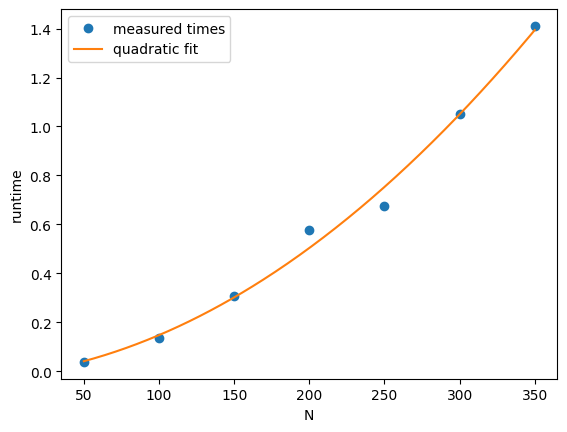

Fit: t(N) = a*N^2 + b*N + c
a = 9.50900809524511e-06
b = 0.0007072785476154937
c = -0.01837051428537902


In [47]:
#2c
import time
N_values = [50,100,150,200,250,300,350] 
times = []
repeats = 1 # per N_value

for N in N_values:
    positions, L = generate_positions(N, phi, sigma, 1.0, 1000000)
    # least for times with same N to calc mean
    t_list =[]
    for _ in range(repeats):
        t0 = time.perf_counter()
        f  = total_forces(positions, L, epsilon, sigma, rc)
        t1 = time.perf_counter()
        t_list.append(t1-t0)
    times.append(np.mean(t_list)) 


times = np.array(times)
N_values_plot = np.array(N_values)
coeff = np.polyfit(N_values_plot, times, 2)
a, b, c = coeff
N_fit = np.linspace(N_values_plot.min(), N_values_plot.max(), 300)
t_fit = a * N_fit**2 + b * N_fit + c

plt.plot(N_values_plot, times, 'o', label='measured times')
plt.plot(N_fit, t_fit, '-', label='quadratic fit')
plt.xlabel('N')
plt.ylabel('runtime')
plt.legend()
plt.show()

print("Fit: t(N) = a*N^2 + b*N + c")
print("a =", a)
print("b =", b)
print("c =", c)


3 Integration of the equations of motion

(a)

Nondimensionalize the equations and pick a sensible time step in terms of $\sigma$, $\epsilon$ and the particle mass $m$.

The velocity-Verlet algorithm for positions $r$, velocities $v$ and forces $f$ consists of the following steps:

$$
v\left(t + \frac{\Delta t}{2}\right) = v(t) + \frac{f(t)}{2m}\Delta t
$$

$$
r(t + \Delta t) = r(t) + v\left(t + \frac{\Delta t}{2}\right)\Delta t
$$

$$
f(t + \Delta t) = f(r(t + \Delta t))
$$

$$
v(t + \Delta t) = v\left(t + \frac{\Delta t}{2}\right) + \frac{f(t+\Delta t)}{2m}\Delta t
$$


In [7]:
#3a

(b)

Implement the velocity-Verlet algorithm to solve the equations of motion.

In [8]:
#3b

(c)

Calculate the kinetic energy at every integer time step and plot the total energy and the temperature as a function of time.

In [9]:
#3c
